In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.cluster import KMeans, DBSCAN

from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)

import warnings
warnings.filterwarnings("ignore")

In [2]:
penguins = sns.load_dataset("penguins")

print("Dataset shape:", penguins.shape)
display(penguins.head())

Dataset shape: (344, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [3]:
print("Dataset info:")
display(penguins.info())

print("\nMissing values:")
display(penguins.isna().sum())

print("\nBasic statistics for numeric columns:")
display(penguins.describe())

print("\nSpecies counts:")
display(penguins["species"].value_counts())

print("\nIsland counts:")
display(penguins["island"].value_counts())

print("\nSex counts:")
display(penguins["sex"].value_counts(dropna=False))

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


None


Missing values:


species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64


Basic statistics for numeric columns:


...

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64


Island counts:


island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64


Sex counts:


sex
Male      168
Female    165
NaN        11
Name: count, dtype: int64

In [4]:
penguins_clean = penguins.dropna().copy()

print("Original shape:", penguins.shape)
print("Cleaned shape:", penguins_clean.shape)

print("\nRemaining missing values:")
display(penguins_clean.isna().sum())

Original shape: (344, 7)
Cleaned shape: (333, 7)

Remaining missing values:


species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

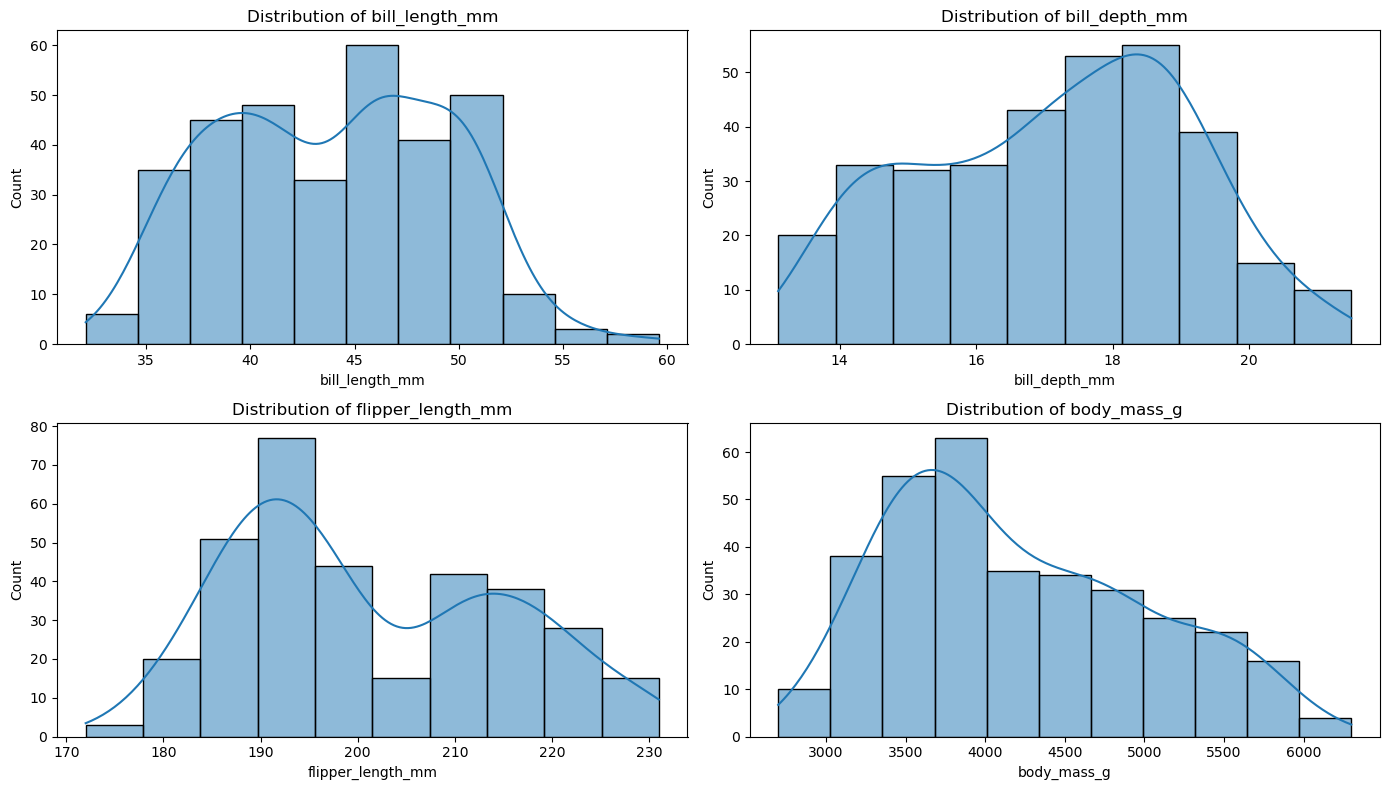

In [5]:
numeric_cols = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g"
]

plt.figure(figsize=(14, 8))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 2, i)
    sns.histplot(data=penguins_clean, x=col, kde=True)
    plt.title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

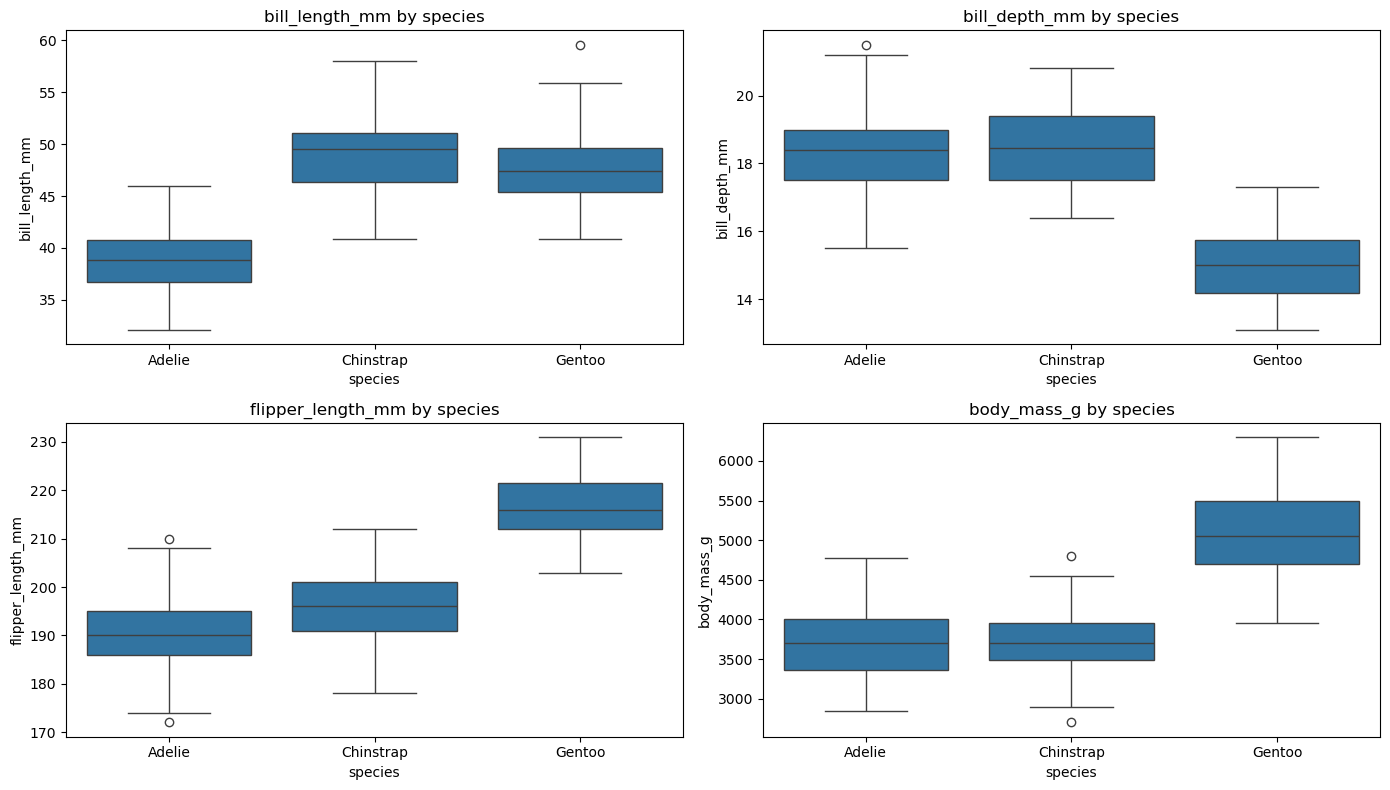

In [6]:
plt.figure(figsize=(14, 8))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=penguins_clean, x="species", y=col)
    plt.title(f"{col} by species")

plt.tight_layout()
plt.show()

In [7]:
X = penguins_clean[numeric_cols]
y_true = penguins_clean["species"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=numeric_cols, index=penguins_clean.index)

display(X_scaled_df.head())

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,-0.896042,0.780732,-1.426752,-0.568475
1,-0.822788,0.119584,-1.069474,-0.506286
2,-0.676280,0.424729,-0.426373,-1.190361
4,-1.335566,1.085877,-0.569284,-0.941606
5,-0.859415,1.747026,-0.783651,-0.692852


In [8]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30,
    learning_rate="auto",
    init="pca"
)
X_tsne = tsne.fit_transform(X_scaled)

projection_df = penguins_clean.copy()
projection_df["PCA1"] = X_pca[:, 0]
projection_df["PCA2"] = X_pca[:, 1]
projection_df["TSNE1"] = X_tsne[:, 0]
projection_df["TSNE2"] = X_tsne[:, 1]

print("PCA explained variance ratio:")
print(pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

display(projection_df.head())

PCA explained variance ratio:
[0.68633893 0.19452929]
Total explained variance: 0.8808682242049916


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,PCA1,PCA2,TSNE1,TSNE2
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male,-1.853593,0.032069,-12.235779,-1.547306
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female,-1.316254,-0.443527,-15.430823,-1.208529
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female,-1.376605,-0.161230,-18.581902,-1.790823
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female,-1.885288,-0.012351,-9.284227,-5.231504
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male,-1.919981,0.817598,-5.817228,-2.679479


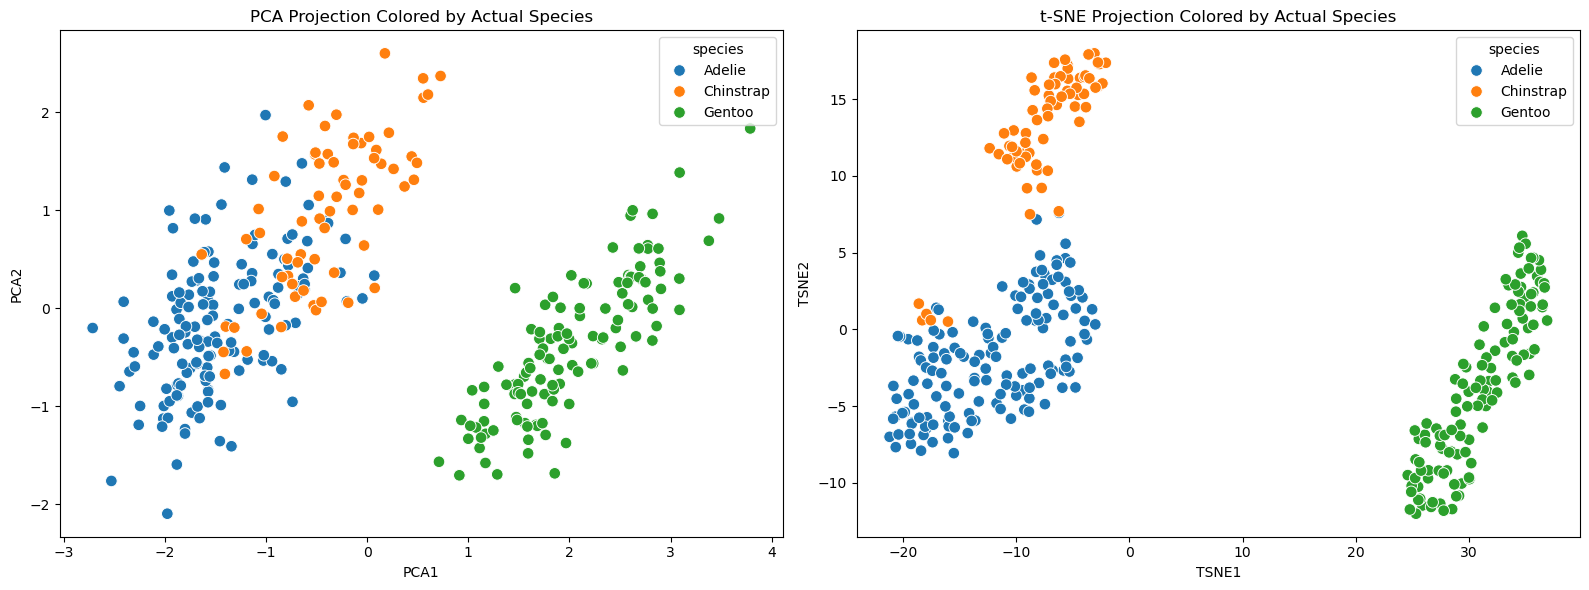

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(
    data=projection_df,
    x="PCA1",
    y="PCA2",
    hue="species",
    ax=axes[0],
    s=70
)
axes[0].set_title("PCA Projection Colored by Actual Species")

sns.scatterplot(
    data=projection_df,
    x="TSNE1",
    y="TSNE2",
    hue="species",
    ax=axes[1],
    s=70
)
axes[1].set_title("t-SNE Projection Colored by Actual Species")

plt.tight_layout()
plt.show()

In [10]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

penguins_clean["kmeans_cluster"] = kmeans_labels

print("K-Means cluster counts:")
display(pd.Series(kmeans_labels).value_counts().sort_index())

K-Means cluster counts:


0    129
1    119
2     85
Name: count, dtype: int64

In [11]:
dbscan_params = [
    {"eps": 0.5, "min_samples": 5},
    {"eps": 0.7, "min_samples": 5},
    {"eps": 0.9, "min_samples": 5},
    {"eps": 1.0, "min_samples": 5},
    {"eps": 0.7, "min_samples": 3},
    {"eps": 0.9, "min_samples": 3},
]

dbscan_results = {}

for params in dbscan_params:
    eps = params["eps"]
    min_samples = params["min_samples"]
    
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(X_scaled)
    
    name = f"DBSCAN_eps{eps}_min{min_samples}"
    dbscan_results[name] = labels
    
    print(f"\n{name}")
    print(pd.Series(labels).value_counts().sort_index())


DBSCAN_eps0.5_min5
-1     66
 0    115
 1     16
 2     27
 3    109
Name: count, dtype: int64

DBSCAN_eps0.7_min5
-1     17
 0    201
 1    115
Name: count, dtype: int64

DBSCAN_eps0.9_min5
-1      2
 0    212
 1    119
Name: count, dtype: int64

DBSCAN_eps1.0_min5
-1      1
 0    213
 1    119
Name: count, dtype: int64

DBSCAN_eps0.7_min3
-1     10
 0    202
 1      4
 2    117
Name: count, dtype: int64

DBSCAN_eps0.9_min3
-1      2
 0    212
 1    119
Name: count, dtype: int64


In [12]:
clustering_scores = []

def safe_silhouette_score(X_data, labels):
    unique_labels = set(labels)
    
    # Silhouette needs at least 2 clusters.
    # If there is only one label total, it cannot be calculated.
    if len(unique_labels) < 2:
        return np.nan
    
    # If DBSCAN produced only one cluster plus noise, silhouette is technically possible,
    # but it may not be very meaningful. We still calculate it for comparison.
    try:
        return silhouette_score(X_data, labels)
    except:
        return np.nan


# K-Means score
clustering_scores.append({
    "method": "KMeans_k3",
    "silhouette": safe_silhouette_score(X_scaled, kmeans_labels),
    "n_clusters_including_noise": len(set(kmeans_labels)),
    "noise_points": np.sum(kmeans_labels == -1)
})


# DBSCAN scores
for name, labels in dbscan_results.items():
    clustering_scores.append({
        "method": name,
        "silhouette": safe_silhouette_score(X_scaled, labels),
        "n_clusters_including_noise": len(set(labels)),
        "noise_points": np.sum(labels == -1)
    })


scores_df = pd.DataFrame(clustering_scores)
scores_df = scores_df.sort_values(by="silhouette", ascending=False)

display(scores_df)

,method,silhouette,n_clusters_including_noise,noise_points
4,DBSCAN_eps1.0_min5,0.466918,3,1
3,DBSCAN_eps0.9_min5,0.451737,3,2
6,DBSCAN_eps0.9_min3,0.451737,3,2
0,KMeans_k3,0.446193,3,0
2,DBSCAN_eps0.7_min5,0.446192,3,17
5,DBSCAN_eps0.7_min3,0.374438,4,10
1,DBSCAN_eps0.5_min5,0.251571,5,66


In [13]:
comparison_scores = []

# KMeans
comparison_scores.append({
    "method": "KMeans_k3",
    "ARI": adjusted_rand_score(y_true, kmeans_labels),
    "NMI": normalized_mutual_info_score(y_true, kmeans_labels)
})

# DBSCAN
for name, labels in dbscan_results.items():
    comparison_scores.append({
        "method": name,
        "ARI": adjusted_rand_score(y_true, labels),
        "NMI": normalized_mutual_info_score(y_true, labels)
    })

comparison_df = pd.DataFrame(comparison_scores)
comparison_df = comparison_df.sort_values(by="ARI", ascending=False)

display(comparison_df)

,method,ARI,NMI
0,KMeans_k3,0.799421,0.789932
1,DBSCAN_eps0.5_min5,0.663400,0.663431
4,DBSCAN_eps1.0_min5,0.650608,0.759976
3,DBSCAN_eps0.9_min5,0.647064,0.749974
6,DBSCAN_eps0.9_min3,0.647064,0.749974
5,DBSCAN_eps0.7_min3,0.641798,0.693607
2,DBSCAN_eps0.7_min5,0.627861,0.673080


In [14]:
best_method = comparison_df.iloc[0]["method"]

print("Best method based on ARI:", best_method)

if best_method == "KMeans_k3":
    best_labels = kmeans_labels
else:
    best_labels = dbscan_results[best_method]

penguins_clean["best_cluster"] = best_labels

print("\nBest cluster label counts:")
display(pd.Series(best_labels).value_counts().sort_index())

Best method based on ARI: KMeans_k3

Best cluster label counts:


0    129
1    119
2     85
Name: count, dtype: int64

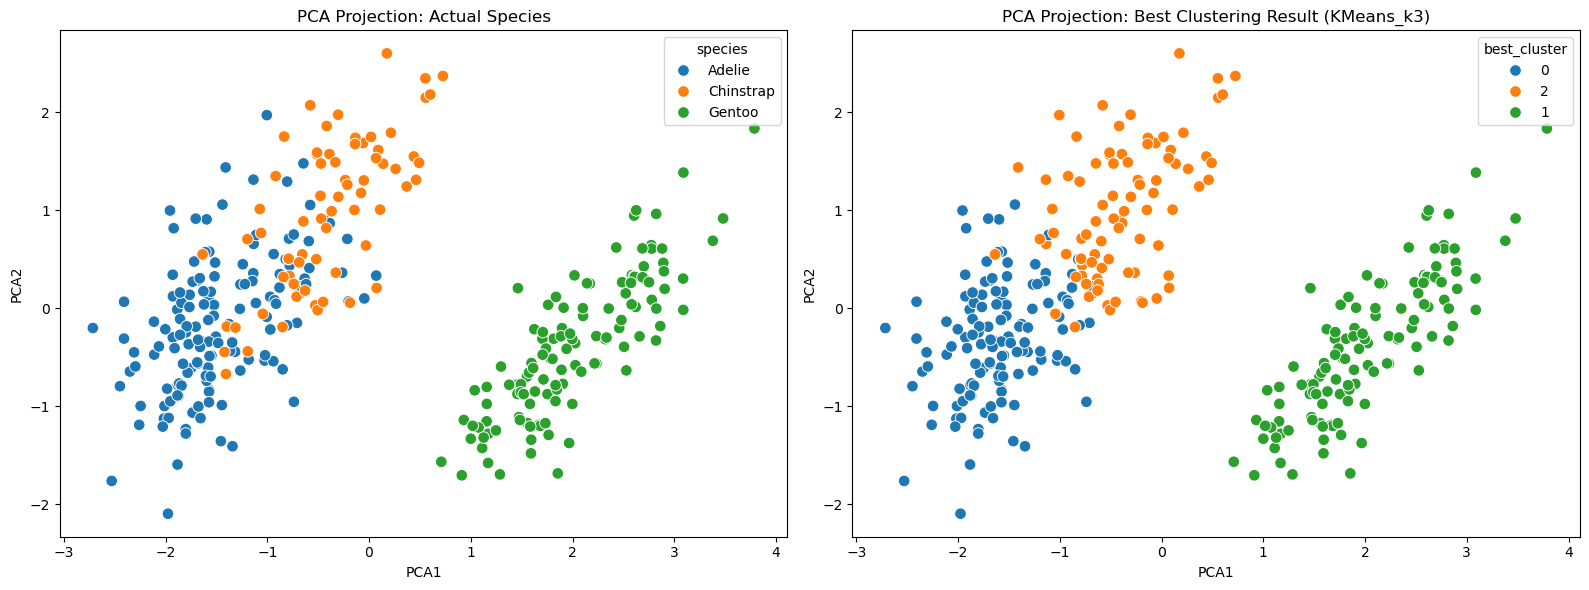

In [15]:
projection_df["best_cluster"] = best_labels.astype(str)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(
    data=projection_df,
    x="PCA1",
    y="PCA2",
    hue="species",
    ax=axes[0],
    s=70
)
axes[0].set_title("PCA Projection: Actual Species")

sns.scatterplot(
    data=projection_df,
    x="PCA1",
    y="PCA2",
    hue="best_cluster",
    ax=axes[1],
    s=70,
    palette="tab10"
)
axes[1].set_title(f"PCA Projection: Best Clustering Result ({best_method})")

plt.tight_layout()
plt.show()

In [16]:
cluster_species_table = pd.crosstab(
    penguins_clean["species"],
    penguins_clean["best_cluster"],
    rownames=["Actual Species"],
    colnames=["Cluster"]
)

display(cluster_species_table)

Cluster,0,1,2
Actual Species,,,
Adelie,124,0,22
Chinstrap,5,0,63
Gentoo,0,119,0


The Palmer Penguins dataset was loaded and cleaned by removing rows with missing values. The numeric features used for clustering were bill length, bill depth, flipper length, and body mass. These features were scaled using `StandardScaler`, because clustering methods such as K-Means and DBSCAN are distance-based and can be strongly affected by feature scale.

The PCA and t-SNE visualizations showed that the species structure is clearly visible to some extent. Gentoo penguins formed the most separate group in both projections, which suggests that their numeric measurements are quite different from the other species. Adelie and Chinstrap penguins were less clearly separated, especially in the PCA plot, where there was noticeable overlap between them.

Several clustering methods were tested. DBSCAN with `eps=1.0` and `min_samples=5` produced the highest silhouette score of about `0.467`, slightly higher than K-Means, which had a silhouette score of about `0.446`. However, when the clustering labels were compared to the actual species labels, K-Means performed best. K-Means achieved an adjusted Rand score of about `0.799` and a normalized mutual information score of about `0.790`.

The crosstab between actual species and K-Means clusters showed that Gentoo penguins were recovered almost perfectly, with all 119 Gentoo samples placed into one cluster. Chinstrap penguins were also mostly grouped together, with 63 out of 68 samples placed in the same cluster. The main weakness was Adelie penguins: most Adelie samples were grouped together, but 22 Adelie samples were placed in the same cluster as Chinstrap. This shows that the largest confusion was between Adelie and Chinstrap, likely because their measurements overlap more than Gentoo.

Overall, the unsupervised methods recovered the species structure fairly well, especially for Gentoo penguins. However, the clustering was not perfect because unsupervised learning does not use the species labels during training. The model only groups penguins based on numeric similarity, so species with overlapping measurements can be mixed together.

## Task 2

In [17]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import make_scorer

In [18]:
penguins = sns.load_dataset("penguins")

print("Original shape:", penguins.shape)

penguins_clean = penguins.dropna().copy()

print("Shape after dropna:", penguins_clean.shape)

display(penguins_clean.head())
display(penguins_clean.isna().sum())

Original shape: (344, 7)
Shape after dropna: (333, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

In [19]:
X = penguins_clean.drop(columns=["species"])
y = penguins_clean["species"]

print("Feature columns:")
print(X.columns.tolist())

print("\nTarget classes:")
print(y.unique())

display(X.head())

Feature columns:
['island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex']

Target classes:
['Adelie' 'Chinstrap' 'Gentoo']


,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Torgersen,39.3,20.6,190.0,3650.0,Male


In [20]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
Categorical features: ['island', 'sex']


In [21]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [22]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVC": SVC(random_state=42)
}

In [23]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro"
}

In [24]:
cv_results = []

for model_name, model in models.items():
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )
    
    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=cv,
        scoring=scoring,
        return_train_score=False
    )
    
    cv_results.append({
        "Model": model_name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision_macro": scores["test_precision_macro"].mean(),
        "Recall_macro": scores["test_recall_macro"].mean(),
        "F1_macro": scores["test_f1_macro"].mean()
    })

results_df = pd.DataFrame(cv_results)
results_df = results_df.sort_values(by="F1_macro", ascending=False)

display(results_df)

,Model,Accuracy,Precision_macro,Recall_macro,F1_macro
0,Logistic Regression,0.99403,0.995833,0.989744,0.992294
2,SVC,0.99403,0.995833,0.989744,0.992294
1,Random Forest,0.99100,0.988643,0.990274,0.989133


In [25]:
best_model_name = results_df.iloc[0]["Model"]

print("Best model based on F1 macro:", best_model_name)

Best model based on F1 macro: Logistic Regression


In [26]:
if best_model_name == "Logistic Regression":
    best_model = LogisticRegression(max_iter=1000, random_state=42)
    param_grid = {
        "model__C": [0.01, 0.1, 1, 10],
        "model__solver": ["lbfgs", "liblinear"],
        "model__penalty": ["l2"]
    }

elif best_model_name == "Random Forest":
    best_model = RandomForestClassifier(random_state=42)
    param_grid = {
        "model__n_estimators": [50, 100, 200],
        "model__max_depth": [None, 3, 5, 10],
        "model__min_samples_split": [2, 5, 10]
    }

elif best_model_name == "SVC":
    best_model = SVC(random_state=42)
    param_grid = {
        "model__C": [0.1, 1, 10],
        "model__kernel": ["linear", "rbf"],
        "model__gamma": ["scale", "auto"]
    }

print("Selected model:", best_model_name)
print("Parameter grid:")
display(param_grid)

Selected model: Logistic Regression
Parameter grid:


{'model__C': [0.01, 0.1, 1, 10],
 'model__solver': ['lbfgs', 'liblinear'],
 'model__penalty': ['l2']}

In [27]:
best_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", best_model)
    ]
)

grid_search = GridSearchCV(
    estimator=best_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
    return_train_score=True
)

grid_search.fit(X, y)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest CV F1 macro score:")
print(grid_search.best_score_)

Best parameters:
{'model__C': 0.1, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}

Best CV F1 macro score:
0.9922939068100358


In [28]:
default_f1 = results_df.loc[
    results_df["Model"] == best_model_name,
    "F1_macro"
].values[0]

tuned_f1 = grid_search.best_score_

comparison_default_tuned = pd.DataFrame({
    "Model Version": [
        f"Default {best_model_name}",
        f"Tuned {best_model_name}"
    ],
    "F1_macro": [
        default_f1,
        tuned_f1
    ]
})

display(comparison_default_tuned)

,Model Version,F1_macro
0,Default Logistic Regression,0.992294
1,Tuned Logistic Regression,0.992294


In [29]:
grid_results_df = pd.DataFrame(grid_search.cv_results_)

columns_to_show = [
    "params",
    "mean_test_score",
    "std_test_score",
    "mean_train_score"
]

grid_results_summary = grid_results_df[columns_to_show].sort_values(
    by="mean_test_score",
    ascending=False
)

display(grid_results_summary.head(10))

,params,mean_test_score,std_test_score,mean_train_score
2,"{'model__C': 0.1, 'model__penalty': 'l2', 'mod...",0.992294,0.015412,0.989076
4,"{'model__C': 1, 'model__penalty': 'l2', 'model...",0.992294,0.015412,0.998187
5,"{'model__C': 1, 'model__penalty': 'l2', 'model...",0.992294,0.015412,0.997291
6,"{'model__C': 10, 'model__penalty': 'l2', 'mode...",0.988655,0.015311,1.000000
7,"{'model__C': 10, 'model__penalty': 'l2', 'mode...",0.988655,0.015311,1.000000
3,"{'model__C': 0.1, 'model__penalty': 'l2', 'mod...",0.984898,0.014342,0.985365
1,"{'model__C': 0.01, 'model__penalty': 'l2', 'mo...",0.942382,0.012123,0.940167
0,"{'model__C': 0.01, 'model__penalty': 'l2', 'mo...",0.902340,0.022024,0.913351


For the supervised classification task, the target variable was `species`, and all other columns were used as features. Rows with missing values were removed using `dropna()`. A preprocessing pipeline was built using `ColumnTransformer`: numeric features were scaled with `StandardScaler`, and categorical features were converted using `OneHotEncoder`.

Three supervised models were trained and evaluated with stratified 5-fold cross-validation: Logistic Regression, Random Forest, and SVC. The models were compared using accuracy, macro precision, macro recall, and macro F1 score. Macro F1 was used as the main selection metric because it gives equal importance to each species instead of favoring only the largest class.

Logistic Regression and SVC produced the best results, both reaching an accuracy of about `0.994` and a macro F1 score of about `0.992`. Random Forest also performed very strongly, with an accuracy of about `0.991` and a macro F1 score of about `0.989`.

Logistic Regression was selected as the best model based on macro F1 score. Although SVC had the same macro F1 score, Logistic Regression was chosen because it reached the same performance with a simpler and more interpretable model.

Hyperparameter tuning was then performed on Logistic Regression using `GridSearchCV` with stratified 5-fold cross-validation. The tested parameters included `C`, `penalty`, and `solver`. The best parameters were:

- `C = 0.1`
- `penalty = l2`
- `solver = lbfgs`

The best tuned cross-validation macro F1 score was `0.992294`, which was the same as the default Logistic Regression score. This means that hyperparameter tuning did not improve the model, likely because the default model was already performing extremely well on this dataset.

Overall, the supervised models performed much better than the unsupervised clustering methods. This is expected because supervised learning uses the actual species labels during training, while clustering only groups samples based on similarity. The Palmer Penguins dataset is highly suitable for supervised classification because the species are well separated using features such as bill measurements, flipper length, body mass, island, and sex.

## Task 3

In [30]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler, OneHotEncoder, label_binarize

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

from sklearn.inspection import permutation_importance

In [31]:
penguins = sns.load_dataset("penguins")
penguins_clean = penguins.dropna().copy()

X = penguins_clean.drop(columns=["species"])
y = penguins_clean["species"]

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Dataset shape after dropna:", penguins_clean.shape)
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)
print("Target classes:", y.unique())

Dataset shape after dropna: (333, 7)
Numeric features: ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
Categorical features: ['island', 'sex']
Target classes: ['Adelie' 'Chinstrap' 'Gentoo']


In [32]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

best_model = LogisticRegression(
    C=0.1,
    penalty="l2",
    solver="lbfgs",
    max_iter=1000,
    random_state=42
)

best_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", best_model)
    ]
)

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

print("\nTraining class counts:")
display(y_train.value_counts())

print("\nTest class counts:")
display(y_test.value_counts())

Training set shape: (266, 6)
Test set shape: (67, 6)

Training class counts:


species
Adelie       117
Gentoo        95
Chinstrap     54
Name: count, dtype: int64


Test class counts:


species
Adelie       29
Gentoo       24
Chinstrap    14
Name: count, dtype: int64

In [34]:
best_pipeline.fit(X_train, y_train)

y_pred = best_pipeline.predict(X_test)

print("Predictions:")
print(y_pred[:10])

Predictions:
['Gentoo' 'Chinstrap' 'Adelie' 'Gentoo' 'Gentoo' 'Gentoo' 'Chinstrap'
 'Adelie' 'Adelie' 'Gentoo']


In [35]:
report = classification_report(y_test, y_pred)

print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        29
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        24

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67



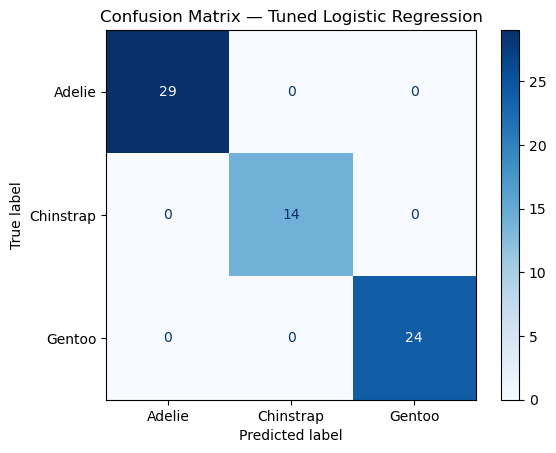

In [36]:
ConfusionMatrixDisplay.from_estimator(
    best_pipeline,
    X_test,
    y_test,
    cmap="Blues",
    values_format="d"
)

plt.title("Confusion Matrix — Tuned Logistic Regression")
plt.show()

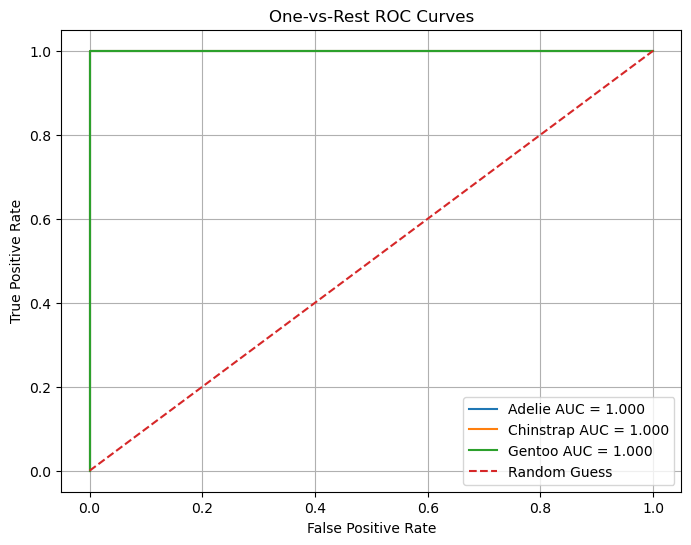

In [37]:
classes = best_pipeline.classes_

y_test_bin = label_binarize(y_test, classes=classes)
y_score = best_pipeline.predict_proba(X_test)

plt.figure(figsize=(8, 6))

for i, class_name in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    
    plt.plot(
        fpr,
        tpr,
        label=f"{class_name} AUC = {roc_auc:.3f}"
    )

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("One-vs-Rest ROC Curves")
plt.legend()
plt.grid(True)
plt.show()

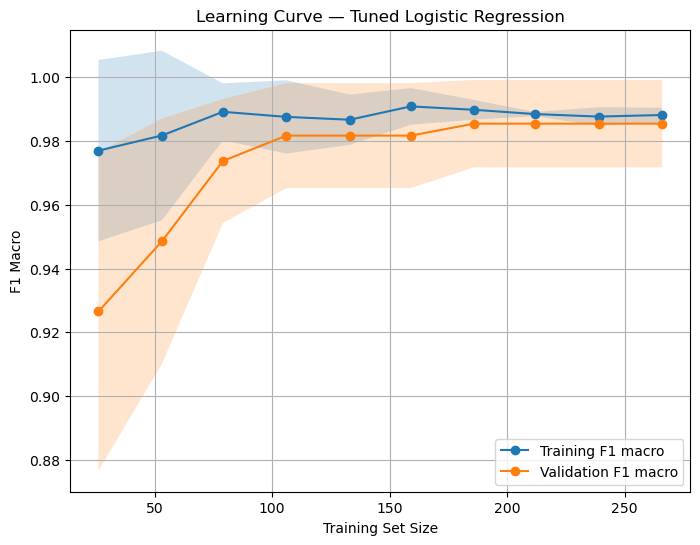

In [38]:
train_sizes = np.linspace(0.1, 1.0, 10)

train_sizes_abs, train_scores, validation_scores = learning_curve(
    estimator=best_pipeline,
    X=X,
    y=y,
    train_sizes=train_sizes,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    shuffle=True,
    random_state=42
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)

validation_mean = validation_scores.mean(axis=1)
validation_std = validation_scores.std(axis=1)

plt.figure(figsize=(8, 6))

plt.plot(train_sizes_abs, train_mean, marker="o", label="Training F1 macro")
plt.plot(train_sizes_abs, validation_mean, marker="o", label="Validation F1 macro")

plt.fill_between(
    train_sizes_abs,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.2
)

plt.fill_between(
    train_sizes_abs,
    validation_mean - validation_std,
    validation_mean + validation_std,
    alpha=0.2
)

plt.xlabel("Training Set Size")
plt.ylabel("F1 Macro")
plt.title("Learning Curve — Tuned Logistic Regression")
plt.legend()
plt.grid(True)
plt.show()

In [39]:
perm_importance = permutation_importance(
    best_pipeline,
    X_test,
    y_test,
    scoring="f1_macro",
    n_repeats=30,
    random_state=42,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm_importance.importances_mean,
    "importance_std": perm_importance.importances_std
})

importance_df = importance_df.sort_values(
    by="importance_mean",
    ascending=False
)

display(importance_df)

,feature,importance_mean,importance_std
1,bill_length_mm,0.275612,0.049926
2,bill_depth_mm,0.048289,0.026184
0,island,0.029473,0.016595
4,body_mass_g,0.018485,0.013727
3,flipper_length_mm,0.007467,0.009441
5,sex,0.007198,0.008816


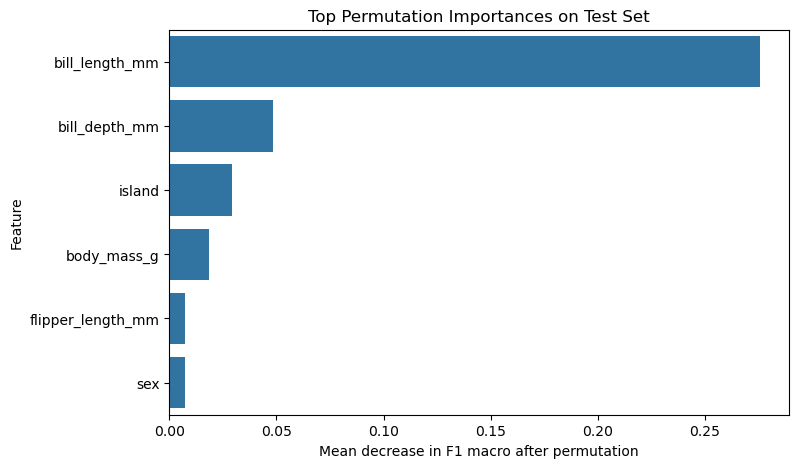

In [40]:
top_importance_df = importance_df.head(10)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=top_importance_df,
    x="importance_mean",
    y="feature",
    orient="h"
)

plt.xlabel("Mean decrease in F1 macro after permutation")
plt.ylabel("Feature")
plt.title("Top Permutation Importances on Test Set")
plt.show()

In [41]:
feature_names = best_pipeline.named_steps["preprocessor"].get_feature_names_out()

print("Transformed feature names:")
for name in feature_names:
    print(name)

Transformed feature names:
num__bill_length_mm
num__bill_depth_mm
num__flipper_length_mm
num__body_mass_g
cat__island_Biscoe
cat__island_Dream
cat__island_Torgersen
cat__sex_Female
cat__sex_Male


The tuned Logistic Regression model from Task 2 was trained using an 80/20 train-test split with `random_state=42`. The split was stratified so that the class distribution of the three penguin species stayed balanced in both the training and test sets.

The model performed perfectly on the held-out test set. The classification report showed precision, recall, and F1-score values of `1.00` for Adelie, Chinstrap, and Gentoo. The overall accuracy was also `1.00` on 67 test samples.

The confusion matrix confirmed this result. All 29 Adelie penguins, 14 Chinstrap penguins, and 24 Gentoo penguins were classified correctly. There were no misclassifications in the test set.

The one-vs-rest ROC curves also showed perfect separation, with an AUC of `1.000` for all three species. This means the model was able to assign very strong probability scores to the correct class for each species.

The learning curve does not show serious overfitting or underfitting. The training F1 score stayed very high, around `0.98–0.99`, while the validation F1 score increased as more training data was used. At larger training sizes, the training and validation curves became close to each other. This suggests that the model generalizes well and is not simply memorizing the training data.

Based on permutation importance, the most important feature was `bill_length_mm`, with the largest decrease in performance when shuffled. The next most important features were `bill_depth_mm`, `island`, and `body_mass_g`. `flipper_length_mm` and `sex` had smaller effects. This suggests that bill measurements were the strongest drivers of the model's predictions.

In this test split, none of the species was difficult to classify because all classes were predicted correctly. However, based on the earlier PCA and clustering results, Adelie and Chinstrap are more likely to be confused in general because their measurements overlap more than Gentoo. Gentoo is usually easier to classify because it is more clearly separated by body size and flipper-related measurements.

There are no obvious signs of data leakage. The target column `species` was removed from the feature set before training. The preprocessing steps were placed inside a pipeline, meaning scaling and one-hot encoding were learned only from the training data during model fitting. The final evaluation was done on a held-out test set that was not used during training.

Overall, the tuned Logistic Regression model performed extremely well on the Palmer Penguins dataset. The results show that the species can be predicted very accurately using the available numeric and categorical features.

## Task 4

In [42]:
import pandas as pd
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

In [43]:
penguins = sns.load_dataset("penguins")
penguins_clean = penguins.dropna().copy()

X = penguins_clean.drop(columns=["species"])
y = penguins_clean["species"]

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

best_model = LogisticRegression(
    C=0.1,
    penalty="l2",
    solver="lbfgs",
    max_iter=1000,
    random_state=42
)

final_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", best_model)
    ]
)

final_pipeline.fit(X, y)

print("Final model trained successfully.")
print("Feature columns:", X.columns.tolist())
print("Classes:", final_pipeline.classes_)

Final model trained successfully.
Feature columns: ['island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex']
Classes: ['Adelie' 'Chinstrap' 'Gentoo']


In [44]:
joblib.dump(final_pipeline, "penguin_model.joblib")

print("Model saved as penguin_model.joblib")

Model saved as penguin_model.joblib


In [46]:
import requests

In [47]:
health_url = "http://127.0.0.1:5000/health"

response = requests.get(health_url)

print("Status code:", response.status_code)
print("Response:")
print(response.json())

Status code: 200
Response:
{'message': 'Penguin species prediction API is running', 'status': 'ok'}


In [48]:
predict_url = "http://127.0.0.1:5000/predict"

valid_penguin = {
    "island": "Biscoe",
    "bill_length_mm": 46.5,
    "bill_depth_mm": 14.4,
    "flipper_length_mm": 217.0,
    "body_mass_g": 4900.0,
    "sex": "Male"
}

response = requests.post(predict_url, json=valid_penguin)

print("Status code:", response.status_code)
print("Response:")
print(response.json())

Status code: 200
Response:
{'class_probabilities': {'Adelie': 0.0194, 'Chinstrap': 0.014, 'Gentoo': 0.9665}, 'predicted_species': 'Gentoo'}


In [50]:
invalid_penguin_missing = {
    "island": "Biscoe",
    "bill_length_mm": 46.5,
    "bill_depth_mm": 14.4,
    "flipper_length_mm": 217.0,
    # body_mass_g is missing
    "sex": "Male"
}

response = requests.post(predict_url, json=invalid_penguin_missing)

print("Status code:", response.status_code)
print("Response:")
print(response.json())

Status code: 400
Response:
{'error': 'Missing required features.', 'missing_features': ['body_mass_g'], 'required_features': ['island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex']}


In [51]:
invalid_penguin_type = {
    "island": "Biscoe",
    "bill_length_mm": "not a number",
    "bill_depth_mm": 14.4,
    "flipper_length_mm": 217.0,
    "body_mass_g": 4900.0,
    "sex": "Male"
}

response = requests.post(predict_url, json=invalid_penguin_type)

print("Status code:", response.status_code)
print("Response:")
print(response.json())

Status code: 400
Response:
{'error': "Feature 'bill_length_mm' must be numeric."}


The best tuned model from the previous tasks was serialized using `joblib.dump()`. The saved object was the full machine learning pipeline, including both preprocessing and the Logistic Regression classifier. This means that the API does not need to manually scale numeric features or encode categorical features. The pipeline handles these steps automatically before making a prediction.

A Flask application was created in `app.py`. The app loads the saved `penguin_model.joblib` file when the server starts. Two endpoints were implemented:

#### `/health`

The `/health` endpoint uses the `GET` method and checks whether the API is running.

Example response:

```json
{
  "status": "ok",
  "message": "Penguin species prediction API is running"
}